<a href="https://colab.research.google.com/github/01PrathamS/Stable_Diffusion_from_scratch/blob/main/notebooks/AutoEncoder_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [19]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Ensure grayscale
    transforms.ToTensor(),  # Convert to PyTorch tensor
    transforms.Normalize((0.5,), (0.5,))  # Normalize
])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)


In [42]:
class AutoEncoder(nn.Module):

  def __init__(self):
    super(AutoEncoder, self).__init__()
    self.encoder = nn.Sequential(
        nn.Linear(28*28, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 32)
    )
    self.decoder = nn.Sequential(
        nn.Linear(32, 64),
        nn.ReLU(),
        nn.Linear(64, 128),
        nn.ReLU(),
        nn.Linear(128, 28*28),
        nn.Tanh()
    )

  def forward(self, x):
    x = self.encoder(x)
    x = self.decoder(x)
    return x




In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = AutoEncoder().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.0005)


def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)

autoencoder.apply(init_weights)

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=784, bias=True)
    (5): Tanh()
  )
)

In [44]:
epochs = 10
for epoch in range(epochs):
    running_loss = 0.0
    for images, _ in trainloader:
        images = images.view(-1, 28*28).to(device)  # Flatten image

        optimizer.zero_grad()
        outputs = autoencoder(images)
        loss = criterion(images,outputs)  # Reconstruction loss

        loss.backward()
        # for name, param in autoencoder.named_parameters():
        #   if param.grad is not None:
        #     print(f"{name} grad norm: {param.grad.norm().item()}")
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(trainloader):.4f}")



Epoch 1/10, Loss: -0.3341
Epoch 2/10, Loss: -0.4071
Epoch 3/10, Loss: -0.4193
Epoch 4/10, Loss: -0.4267
Epoch 5/10, Loss: -0.4314
Epoch 6/10, Loss: -0.4345
Epoch 7/10, Loss: -0.4376
Epoch 8/10, Loss: -0.4407
Epoch 9/10, Loss: -0.4428
Epoch 10/10, Loss: -0.4440


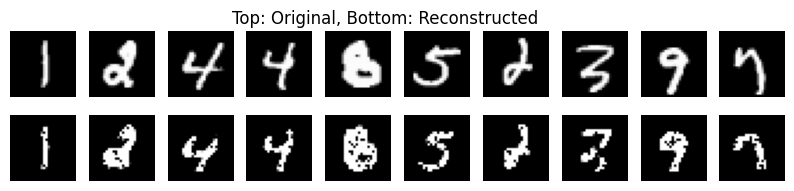

In [45]:
def visualize_results(model, dataloader):
    model.eval()
    images, _ = next(iter(dataloader))
    images = images.view(-1, 28*28).to(device)

    with torch.no_grad():
        reconstructed = model(images)

    # Convert tensors to numpy arrays
    images = images.cpu().view(-1, 28, 28).numpy()
    reconstructed = reconstructed.cpu().view(-1, 28, 28).numpy()

    fig, axes = plt.subplots(2, 10, figsize=(10, 2))
    for i in range(10):
        axes[0, i].imshow(images[i], cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(reconstructed[i], cmap="gray")
        axes[1, i].axis("off")

    plt.suptitle("Top: Original, Bottom: Reconstructed")
    plt.show()

visualize_results(autoencoder, trainloader)